In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/zomato_clean_final.csv')

In [3]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,City,Time_taken (min),Time_Orderd_original,Time_Order_picked_original,Order_Day,Order_Month,Order_Weekday,Order_Hour,Missing_Order_Time,Delivery_Speed
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,2022-02-12,21:55,...,Metropolitan,46,21:55,22:10,12,2,Saturday,22,False,Slow
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,2022-02-13,14:55,...,Metropolitan,23,14:55,15:05,13,2,Sunday,15,False,Medium
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,2022-03-04,17:30,...,Metropolitan,21,17:30,17:40,4,3,Friday,17,False,Medium
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,2022-02-13,09:20,...,Metropolitan,20,09:20,09:30,13,2,Sunday,9,False,Fast
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,2022-02-14,19:50,...,Metropolitan,41,19:50,20:05,14,2,Monday,20,False,Slow


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  str    
 1   Delivery_person_ID           45584 non-null  str    
 2   Delivery_person_Age          45584 non-null  float64
 3   Delivery_person_Ratings      45584 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  str    
 9   Time_Orderd                  43853 non-null  str    
 10  Time_Order_picked            45584 non-null  str    
 11  Weather_conditions           45584 non-null  str    
 12  Road_traffic_density         45584 non-null  str    
 13  Vehicle_condition          

In [5]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [6]:
df.columns.tolist()

['ID',
 'Delivery_person_ID',
 'Delivery_person_Age',
 'Delivery_person_Ratings',
 'Restaurant_latitude',
 'Restaurant_longitude',
 'Delivery_location_latitude',
 'Delivery_location_longitude',
 'Order_Date',
 'Time_Orderd',
 'Time_Order_picked',
 'Weather_conditions',
 'Road_traffic_density',
 'Vehicle_condition',
 'Type_of_order',
 'Type_of_vehicle',
 'multiple_deliveries',
 'Festival',
 'City',
 'Time_taken (min)',
 'Time_Orderd_original',
 'Time_Order_picked_original',
 'Order_Day',
 'Order_Month',
 'Order_Weekday',
 'Order_Hour',
 'Missing_Order_Time',
 'Delivery_Speed']

# 1.Delivery Performance Analysis

In [7]:
df['Time_taken (min)'].describe()

count    45584.000000
mean        26.293963
std          9.384298
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken (min), dtype: float64

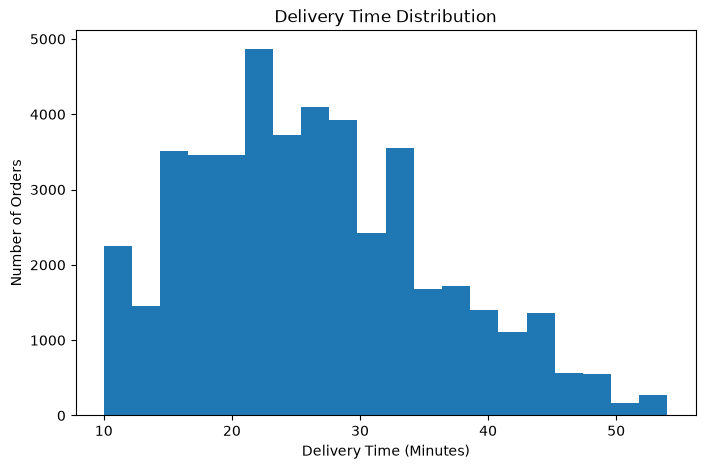

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df['Time_taken (min)'], bins=20)
plt.title('Delivery Time Distribution')
plt.xlabel('Delivery Time (Minutes)')
plt.ylabel('Number of Orders')
plt.show()

In [9]:
round(df['Delivery_Speed'].value_counts(normalize=True)*100,2)

Delivery_Speed
Medium    51.40
Fast      31.04
Slow      17.56
Name: proportion, dtype: float64

# 2. Traffic Impact Analysis

In [11]:
df.groupby('Road_traffic_density')['Time_taken (min)'].mean().sort_values()

Road_traffic_density
Low       21.463893
Medium    26.699680
High      27.240109
Jam       31.176038
Name: Time_taken (min), dtype: float64

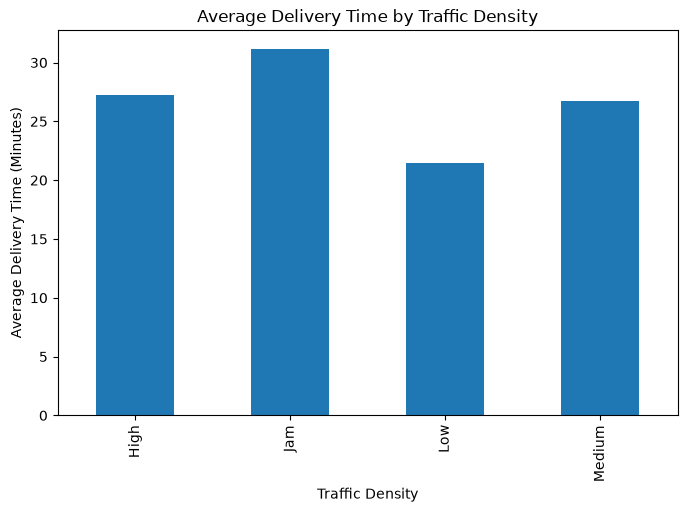

In [12]:
traffic_avg = df.groupby('Road_traffic_density')['Time_taken (min)'].mean()

traffic_avg.plot(kind='bar', figsize=(8,5))
plt.title('Average Delivery Time by Traffic Density')
plt.ylabel('Average Delivery Time (Minutes)')
plt.xlabel('Traffic Density')
plt.show()

# 3. Weather Impact Analysis

In [13]:
df.groupby('Weather_conditions')['Time_taken (min)'].mean().sort_values()

Weather_conditions
Sunny         21.856770
Stormy        25.868803
Sandstorms    25.875500
Windy         26.118836
Fog           28.738179
Cloudy        28.917164
Name: Time_taken (min), dtype: float64

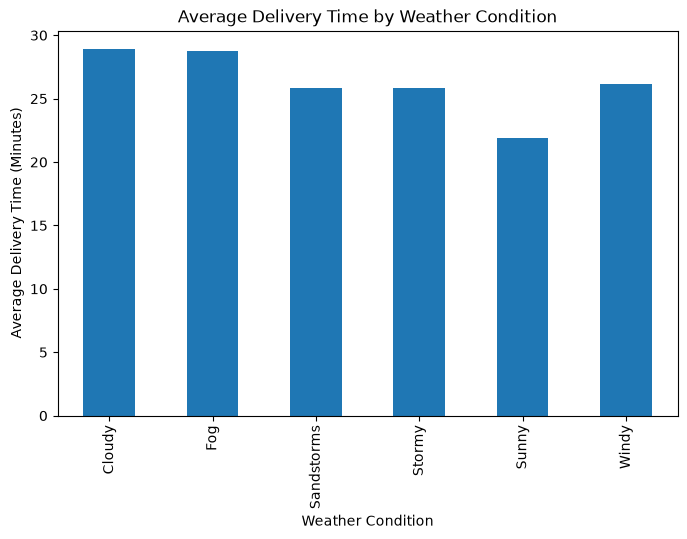

In [14]:
weather_avg = df.groupby('Weather_conditions')['Time_taken (min)'].mean()

weather_avg.plot(kind='bar', figsize=(8,5))
plt.title('Average Delivery Time by Weather Condition')
plt.ylabel('Average Delivery Time (Minutes)')
plt.xlabel('Weather Condition')
plt.show()

# 4. City Analysis

In [17]:
df['City'].value_counts()

City
Metropolitan    35287
Urban           10133
Semi-Urban        164
Name: count, dtype: int64

In [15]:
df.groupby('City')['Time_taken (min)'].mean().sort_values()

City
Urban           22.983322
Metropolitan    27.135716
Semi-Urban      49.731707
Name: Time_taken (min), dtype: float64

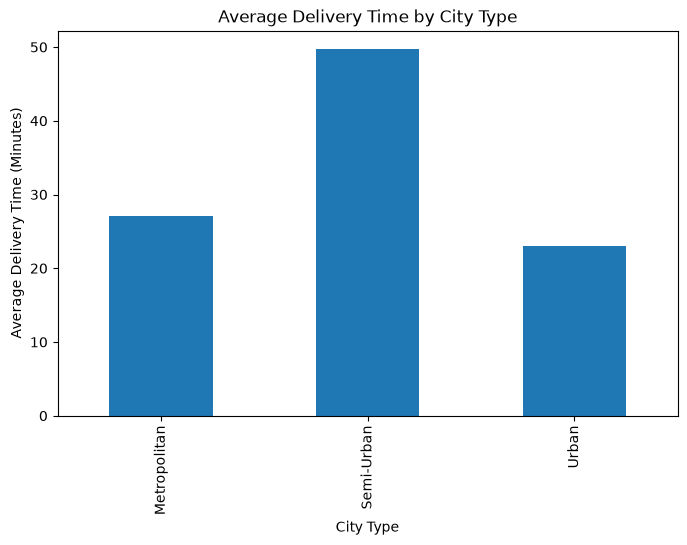

In [16]:
city_avg = df.groupby('City')['Time_taken (min)'].mean()

city_avg.plot(kind='bar', figsize=(8,5))
plt.title('Average Delivery Time by City Type')
plt.ylabel('Average Delivery Time (Minutes)')
plt.xlabel('City Type')
plt.show()

# 5. Driver Performance Analysis

- Do better-rated delivery partners deliver faster?

In [21]:
df.groupby('Delivery_person_Ratings')['Time_taken (min)'].mean().sort_index()

Delivery_person_Ratings
1.0    26.000000
2.5    37.300000
2.6    38.590909
2.7    35.863636
2.8    36.631579
2.9    38.526316
3.0    32.666667
3.1    36.551724
3.2    36.344828
3.3    36.040000
3.4    35.718750
3.5    37.056225
3.6    37.289855
3.7    37.360000
3.8    37.100877
3.9    37.492386
4.0    34.744661
4.1    34.530070
4.2    34.532440
4.3    34.629524
4.4    34.841176
4.5    23.642338
4.6    24.567743
4.7    24.644010
4.8    24.023929
4.9    24.123153
5.0    25.510496
Name: Time_taken (min), dtype: float64

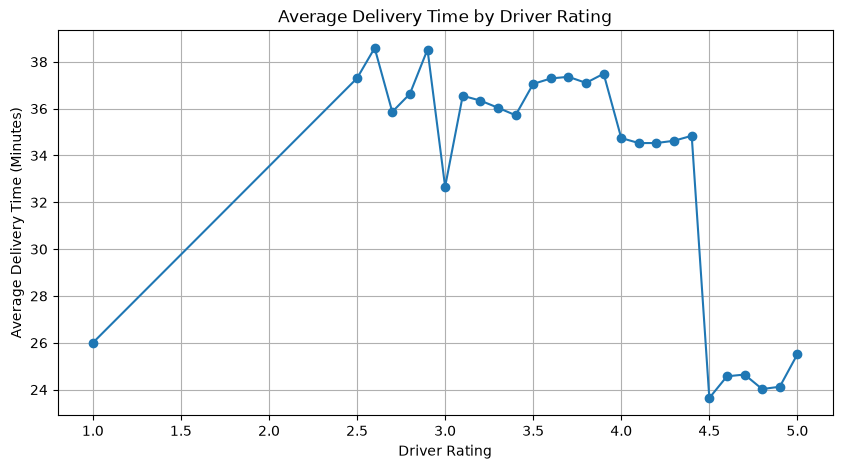

In [19]:
rating_avg = df.groupby('Delivery_person_Ratings')['Time_taken (min)'].mean()

plt.figure(figsize=(10,5))
plt.plot(rating_avg.index, rating_avg.values, marker='o')
plt.title('Average Delivery Time by Driver Rating')
plt.xlabel('Driver Rating')
plt.ylabel('Average Delivery Time (Minutes)')
plt.grid(True)
plt.show()

In [22]:
df[['Delivery_person_Ratings','Time_taken (min)']].corr()

,Delivery_person_Ratings,Time_taken (min)
Delivery_person_Ratings,1.000000,-0.332988
Time_taken (min),-0.332988,1.000000


# 6. Driver Age Analysis

In [23]:
df.groupby('Delivery_person_Age')['Time_taken (min)'].mean()

Delivery_person_Age
15.0    26.000000
20.0    22.898876
21.0    22.908500
22.0    22.927985
23.0    23.196069
24.0    23.059729
25.0    22.819227
26.0    22.948124
27.0    23.053023
28.0    23.166590
29.0    22.916933
30.0    27.941176
31.0    29.659906
32.0    29.885961
33.0    29.489936
34.0    29.605543
35.0    29.607253
36.0    29.500885
37.0    29.250674
38.0    29.451758
39.0    29.739739
50.0    23.943396
Name: Time_taken (min), dtype: float64

In [24]:
age_corr = df[['Delivery_person_Age','Time_taken (min)']].corr()
age_corr

,Delivery_person_Age,Time_taken (min)
Delivery_person_Age,1.000000,0.292909
Time_taken (min),0.292909,1.000000


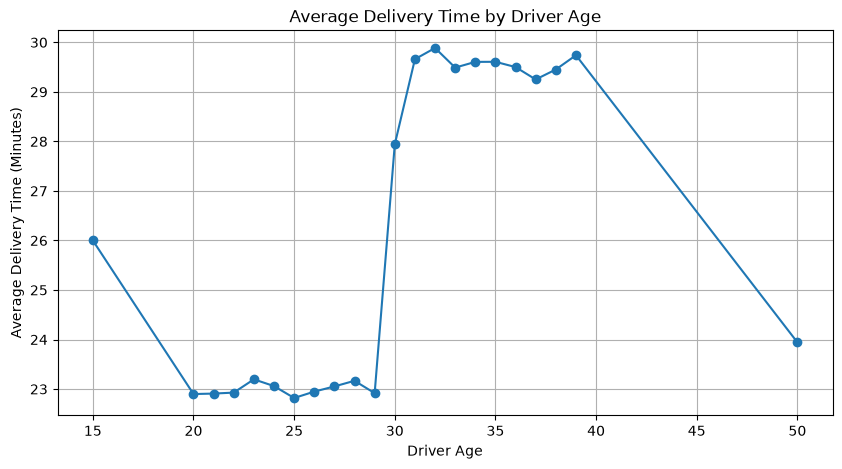

In [25]:
plt.figure(figsize=(10,5))

age_avg = df.groupby('Delivery_person_Age')['Time_taken (min)'].mean()
plt.plot(age_avg.index,age_avg.values,marker='o')
plt.title('Average Delivery Time by Driver Age')
plt.xlabel('Driver Age')
plt.ylabel('Average Delivery Time (Minutes)')
plt.grid(True)
plt.show()

# 7. Vehicle Type Impact

In [26]:
df.groupby('Type_of_vehicle')['Time_taken (min)'].mean().sort_values()

Type_of_vehicle
electric_scooter    24.470110
scooter             24.478819
bicycle             26.426471
motorcycle          27.605774
Name: Time_taken (min), dtype: float64

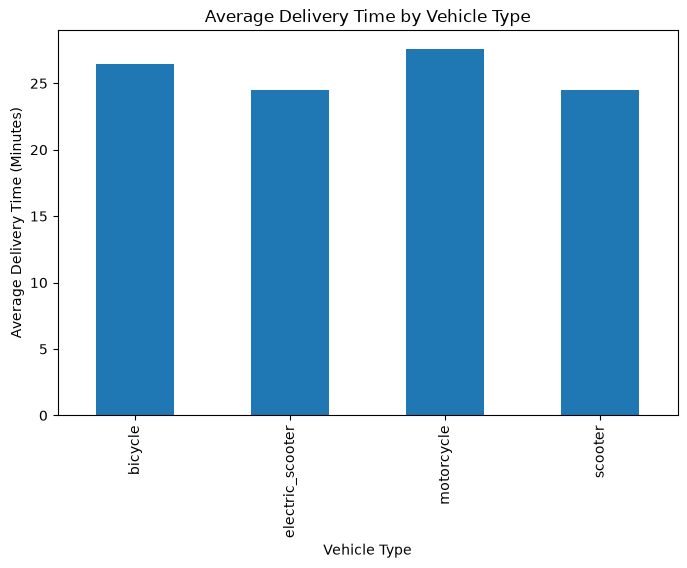

In [27]:
vehicle_avg = df.groupby('Type_of_vehicle')['Time_taken (min)'].mean()

vehicle_avg.plot(kind='bar', figsize=(8,5))
plt.title('Average Delivery Time by Vehicle Type')
plt.ylabel('Average Delivery Time (Minutes)')
plt.xlabel('Vehicle Type')
plt.show()

# 8. Correlation Analysis

In [ ]:
corr_cols = ['Delivery_person_Age','Delivery_person_Ratings','Vehicle_condition','multiple_deliveries','Order_Hour','Time_taken (min)']

corr_matrix = df[corr_cols].corr()
corr_matrix

,Delivery_person_Age,Delivery_person_Ratings,Vehicle_condition,multiple_deliveries,Order_Hour,Time_taken (min)
Delivery_person_Age,1.000000,-0.080737,0.004649,0.111325,-0.002092,0.292909
Delivery_person_Ratings,-0.080737,1.000000,0.029319,-0.112770,-0.054075,-0.332988
Vehicle_condition,0.004649,0.029319,1.000000,-0.095547,0.008750,-0.234456
multiple_deliveries,0.111325,-0.112770,-0.095547,1.000000,0.067761,0.378268
Order_Hour,-0.002092,-0.054075,0.008750,0.067761,1.000000,0.184455
Time_taken (min),0.292909,-0.332988,-0.234456,0.378268,0.184455,1.000000


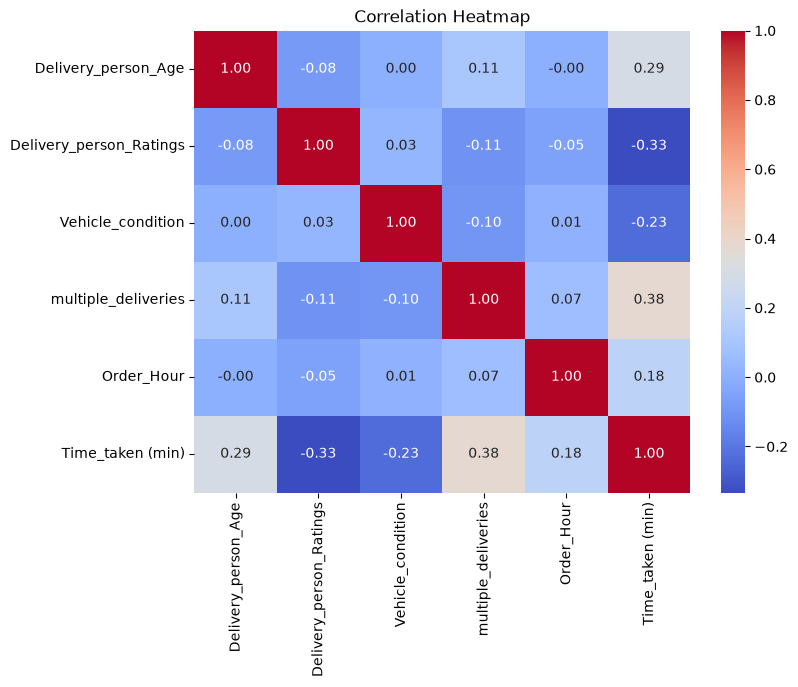

In [29]:
plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [30]:
df.to_csv("../data/processed/zomato_dashboard_dataset.csv",index=False)